# 05 · Unsupervised Modeling

Cluster zip codes by pre-disaster vulnerability profile (NO storm features, NO target). K-Means, PCA, and DBSCAN — fitted on TRAIN split only, then applied to val/test to avoid leakage.

In [1]:
import sys, os
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 60)
from config import (
    DATA_PATHS, HURRICANE_META, STATES_IN_SCOPE,
    TARGET_COL, TARGET_CLASS_COL, FEATURE_GROUPS,
    RANDOM_STATE, SEVERITY_BINS, SEVERITY_LABELS,
)
RAW = DATA_PATHS['raw']; INTERIM = DATA_PATHS['interim']
PROC = DATA_PATHS['processed']; MODELS = DATA_PATHS['models']
OUT = DATA_PATHS['outputs']


In [2]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency
df = pd.read_csv(PROC / 'abt.csv', dtype={'zip_code': str})
feat = (FEATURE_GROUPS['demographics'] + FEATURE_GROUPS['svi']
        + FEATURE_GROUPS['food_access'] + FEATURE_GROUPS['flood'])
feat = [c for c in feat if c in df.columns]
train = df[df['train_test_split']=='TRAIN'].dropna(subset=feat).copy()
Xtr = StandardScaler().fit(train[feat])
scaler = Xtr; Xtr = scaler.transform(train[feat])
print('train shape:', Xtr.shape)

train shape: (8004, 19)


## K-Means — elbow + silhouette

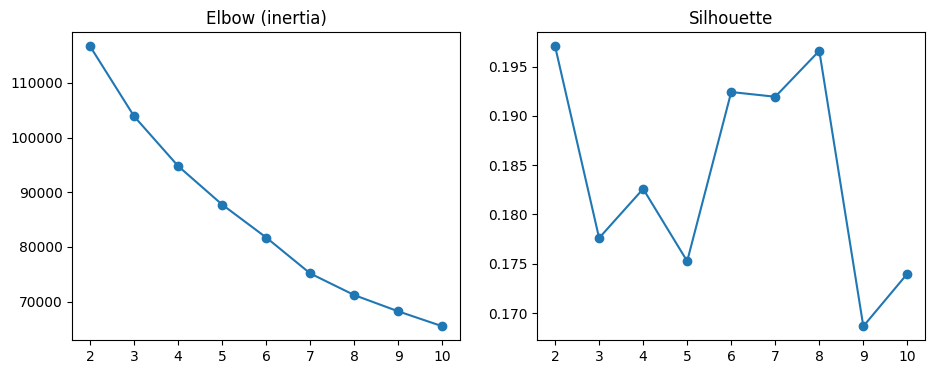

In [3]:
inertias, sils = [], []
ks = range(2, 11)
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xtr)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xtr, km.labels_))
fig, ax = plt.subplots(1,2,figsize=(11,4))
ax[0].plot(ks, inertias, 'o-'); ax[0].set_title('Elbow (inertia)')
ax[1].plot(ks, sils, 'o-'); ax[1].set_title('Silhouette')
plt.savefig(OUT / 'kmeans_elbow.png', dpi=150); plt.show()

In [4]:
K = int(np.argmax(sils) + 2)
print('chosen k =', K)
km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(Xtr)
train['cluster'] = km.labels_
centers = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_), columns=feat)
centers

chosen k = 2


,population,median_income,pct_poverty,pct_renters,pct_elderly_65plus,pct_minority,pct_no_vehicle,pct_mobile_homes,svi_socioeconomic,svi_household_comp,svi_minority_lang,svi_housing_transport,svi_overall,food_desert_flag,snap_retailer_count,snap_retailers_per_1k,dist_nearest_supermarket_mi,snap_participation_pct,pct_in_100yr_floodplain
0,26180.168172,-1.712954e+07,10.191427,9.514132,17.156415,25.072471,1.275574,7.088017,0.481083,0.485358,0.485199,0.436332,0.469536,0.056774,34.385806,2.168322,0.805572,145.568770,0.0
1,27803.404592,-4.123317e+06,19.005109,14.095455,14.082185,45.443728,2.758296,6.444410,0.764463,0.717432,0.734045,0.612113,0.764985,0.196184,74.497018,3.079041,0.281491,286.017829,0.0


In [5]:
# cluster vs damage severity — chi-square independence
tab = pd.crosstab(train['cluster'], train['damage_severity_class'])
chi2, p, dof, _ = chi2_contingency(tab)
print('chi2=%.2f dof=%d p=%.3g' % (chi2, dof, p)); tab

chi2=69.93 dof=3 p=4.41e-15


damage_severity_class,High,Low,Medium,Severe
cluster,,,,
0,774,2204,505,978
1,433,1632,293,954


## PCA

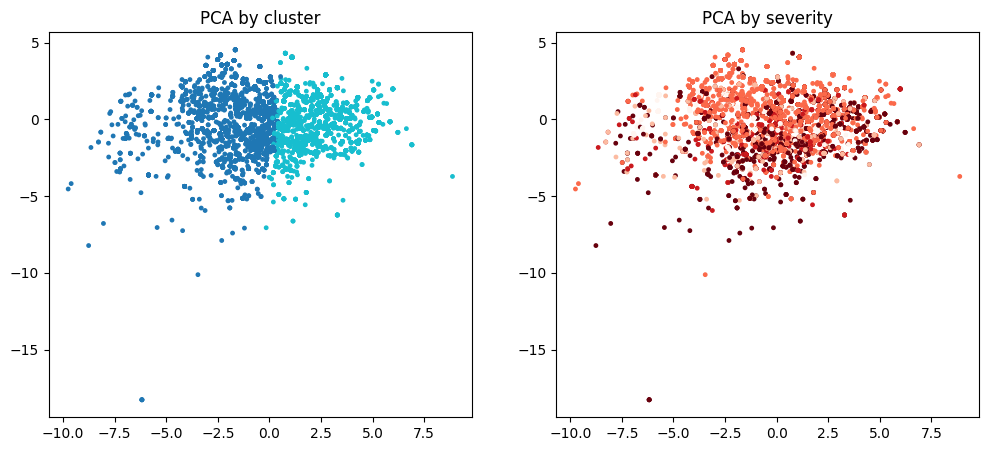

explained variance: [0.30157193 0.47880224]
Top PC1:
svi_overall               0.392426
svi_socioeconomic         0.380058
svi_household_comp        0.312532
svi_minority_lang         0.310808
snap_participation_pct    0.298999
Name: PC1, dtype: float64
Top PC2:
population               0.466337
pct_mobile_homes         0.413381
pct_elderly_65plus       0.342070
snap_retailers_per_1k    0.253807
svi_minority_lang        0.251120
Name: PC2, dtype: float64


In [6]:
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(Xtr)
proj = pca.transform(Xtr)
fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].scatter(proj[:,0], proj[:,1], c=train['cluster'], s=6, cmap='tab10')
ax[0].set_title('PCA by cluster')
sev_code = train['damage_severity_class'].astype('category').cat.codes
ax[1].scatter(proj[:,0], proj[:,1], c=sev_code, s=6, cmap='Reds')
ax[1].set_title('PCA by severity')
plt.savefig(OUT / 'pca_scatter.png', dpi=150); plt.show()
print('explained variance:', pca.explained_variance_ratio_.cumsum())
loadings = pd.DataFrame(pca.components_.T, index=feat, columns=['PC1','PC2'])
print('Top PC1:'); print(loadings['PC1'].abs().sort_values(ascending=False).head(5))
print('Top PC2:'); print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

## DBSCAN (eps via k-distance)

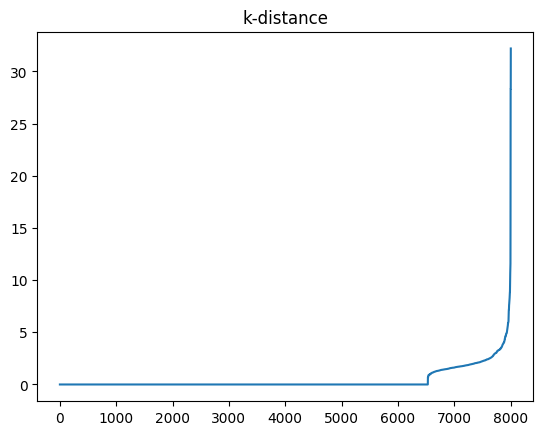

DBSCAN clusters: 135
noise pct: 8.9%


In [7]:
nn = NearestNeighbors(n_neighbors=5).fit(Xtr)
dists, _ = nn.kneighbors(Xtr)
kd = np.sort(dists[:, -1])
plt.plot(kd); plt.title('k-distance'); plt.savefig(OUT / 'dbscan_kdist.png'); plt.show()
eps = float(np.percentile(kd, 90))
db = DBSCAN(eps=eps, min_samples=5).fit(Xtr)
print('DBSCAN clusters:', len(set(db.labels_))-(1 if -1 in db.labels_ else 0))
print('noise pct: %.1f%%' % (100*(db.labels_==-1).mean()))

## Apply to full ABT and save

In [8]:
all_feat = df.dropna(subset=feat).copy()
all_feat['cluster_label'] = km.predict(scaler.transform(all_feat[feat]))
df = df.merge(all_feat[['zip_code','disaster_number','cluster_label']],
              on=['zip_code','disaster_number'], how='left')
df.to_csv(PROC / 'abt_with_clusters.csv', index=False)
print('saved abt_with_clusters', df.shape)

saved abt_with_clusters (1691105, 66)
